In [1]:
import pandas as pd
cars = pd.read_csv('data/car.csv')
cars.head(5)

,minute,second
0,0,0
1,0,1
2,0,2
3,0,3
4,0,3


In [2]:
traffic = cars.shape[0] / cars['minute'].value_counts().shape[0]
traffic

35.1

Text(0, 0.5, 'P(X=k)')

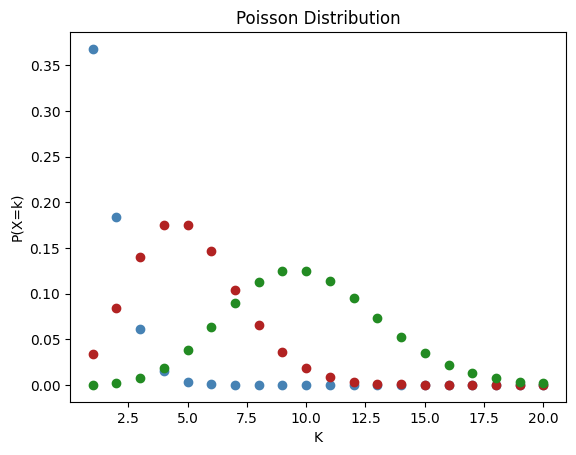

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson
color_set = ('steelblue', 'firebrick', 'forestgreen')
lambdas = (1, 5, 10)
x = np.linspace(1, 20, num=20)
poisson.pmf(x, lambdas[0])


plt.scatter(x=x, y=poisson.pmf(x, lambdas[0], loc=0), c=color_set[0])
plt.scatter(x=x, y=poisson.pmf(x, lambdas[1], loc=0), c=color_set[1])
plt.scatter(x=x, y=poisson.pmf(x, lambdas[2], loc=0), c=color_set[2])
plt.title('Poisson Distribution')
plt.xlabel('K')
plt.ylabel('P(X=k)')



[0.02131227 0.02770595 0.03473139 0.04203695 0.04918324 0.05568812
 0.0610829  0.06497    0.06707197 0.0672636  0.06558201 0.06221429
 0.05746635 0.05171972 0.04538405 0.03885318 0.03247015 0.02650471
 0.02114353 0.01649195 0.01258408]


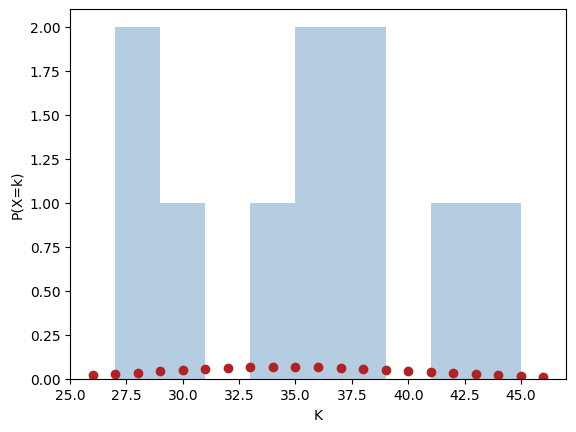

In [4]:
def plot_hist_pois(Ks, Lambda):
    bins = (max(Ks) - min(Ks)) // 2
    rng = list(iter(range(min(Ks) - 1, max(Ks) + 2)))
    probs = poisson.pmf(rng, Lambda)
    plt.clf
    plt.hist(x=Ks, bins=bins, color=color_set[0], alpha=0.4)
    plt.scatter(rng, probs, color=color_set[1])
    print(probs)
    plt.xlabel('K')
    plt.ylabel('P(X=k)')

ks = [cars[cars['minute'] == i].shape[0] for i in range(10)]
Lambda = 35.1
plot_hist_pois(ks, Lambda)

[3.25986859e-08 1.27134875e-07 4.46243411e-07 1.42392216e-06
 4.16497231e-06 1.12454252e-05 2.81938876e-05 6.59736969e-05
 1.44729798e-04 2.98824465e-04 5.82707706e-04 1.07647581e-03
 1.88921505e-03 3.15768802e-03 5.03794770e-03 7.68834628e-03
 1.12442064e-02 1.57868658e-02 2.13122689e-02 2.77059495e-02
 3.47313867e-02 4.20369543e-02 4.91832365e-02]
[23, 9, 21, 16, 13, 20, 17, 20, 16, 17, 13, 18, 21, 13, 14, 17, 17, 18, 29, 19]


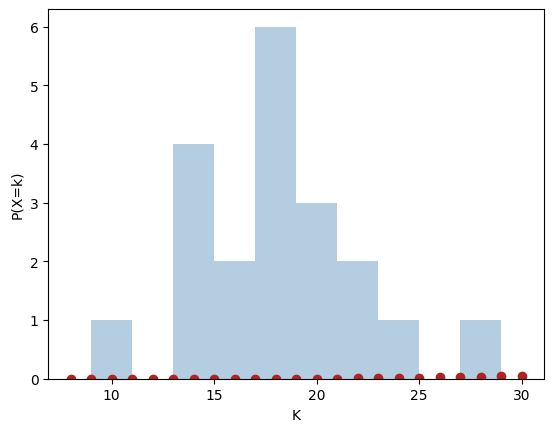

In [5]:
new_Ks = [cars[((cars['minute'] == i) & (cars[' second'] < 30))].shape[0] for i in range(10)]
new_Ks += [cars[((cars['minute'] == i) & (cars[' second'] >= 30))].shape[0] for i in range(10)]

plot_hist_pois(new_Ks, Lambda)
print(new_Ks)

[0.00533124 0.01039592 0.01824484 0.02910881 0.04257163 0.05747171
 0.07204489 0.08429252 0.09245836 0.09544966 0.09306342 0.08596121
 0.07543096 0.06303873 0.05028772 0.03837171 0.02805932 0.01969764
 0.01329591 0.00864234 0.00541689 0.00327816 0.00191772]


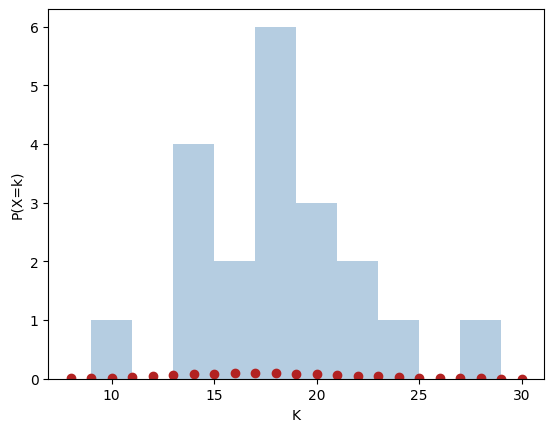

In [6]:
plot_hist_pois(new_Ks, Lambda/2)


In [7]:
from scipy.stats import poisson
1 - poisson.cdf(10, 15, loc = 0)

np.float64(0.881535588470985)

In [8]:
import math
1 - sum([math.exp(-15) * (15 ** x) / math.factorial(x) for x in range(0, 11)])

0.8815355884709849

In [9]:
from scipy.stats import poisson
1 - poisson.cdf(15, 16, loc = 0)

np.float64(0.533255108612279)

In [10]:
import math
1 - sum([math.exp(-16) * (16 ** x) / math.factorial(x) for x in range(0, 16)])

0.5332551086122792